# Carregar dados e bibliotecas

In [ ]:
# bibliotecas
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array


In [ ]:
import os
import zipfile

# Caminho do arquivo ZIP e da pasta de destino
zip_path = '/content/Frutas.v2-version-2_70-20-10-pos-dataaugmentation.folder.zip'
destination_folder = '/content/Frutas'

# Verificar se o arquivo ZIP existe
if not os.path.exists(zip_path):
    print(f"Erro: O arquivo ZIP '{zip_path}' não foi encontrado.")
else:
    # Criar a pasta de destino, se ainda não existir
    os.makedirs(destination_folder, exist_ok=True)

    try:
        # Verificar se o arquivo é um ZIP válido
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)
        print(f"Arquivos descompactados em: {destination_folder}")
    except zipfile.BadZipFile:
        print(f"Erro: O arquivo '{zip_path}' não é um arquivo ZIP válido.")
    except Exception as e:
        print(f"Ocorreu um erro ao descompactar o arquivo: {e}")

Arquivos descompactados em: /content/Frutas


In [ ]:
input_size = (520, 520)

# carregar imagens
train_set = tf.keras.utils.image_dataset_from_directory(
    #"/content/Frutas/train",
    "/content/Frutas/train",
    seed=1337,
    image_size=input_size,
    label_mode='categorical'
)

val_set = tf.keras.utils.image_dataset_from_directory(
    #"/content/Frutas/valid",
    "/content/Frutas/valid",
    seed=1337,
    image_size=input_size,
    label_mode='categorical'
)

test_set = tf.keras.utils.image_dataset_from_directory(
    #"/content/Frutas/test",
    "/content/Frutas/test",
    seed=1337,
    image_size=input_size,
    label_mode='categorical'
)

# classes
class_names = train_set.class_names

Found 1377 files belonging to 5 classes.
Found 393 files belonging to 5 classes.
Found 196 files belonging to 5 classes.


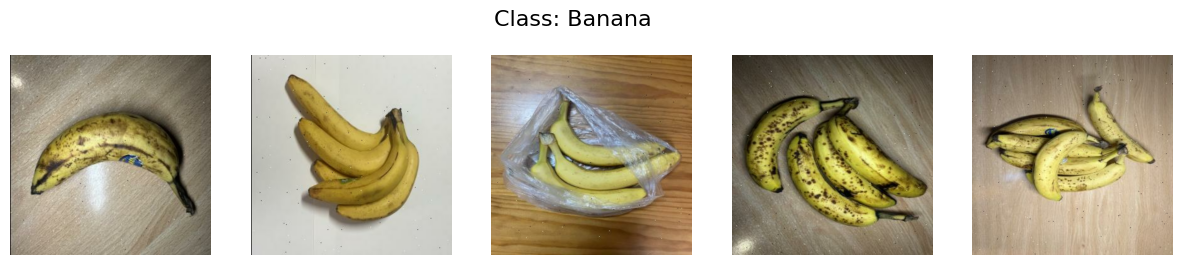

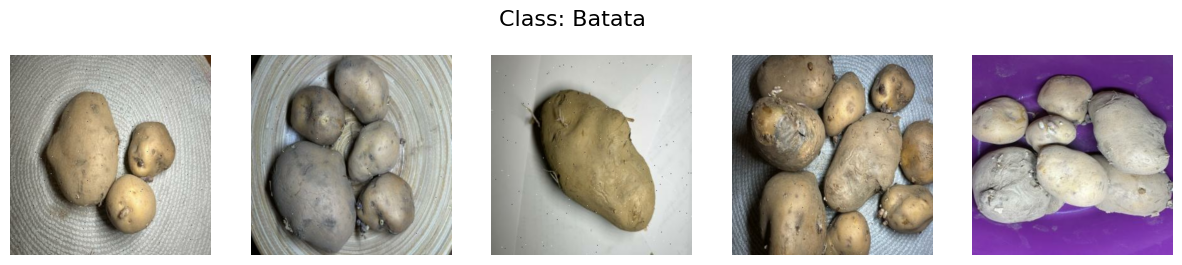

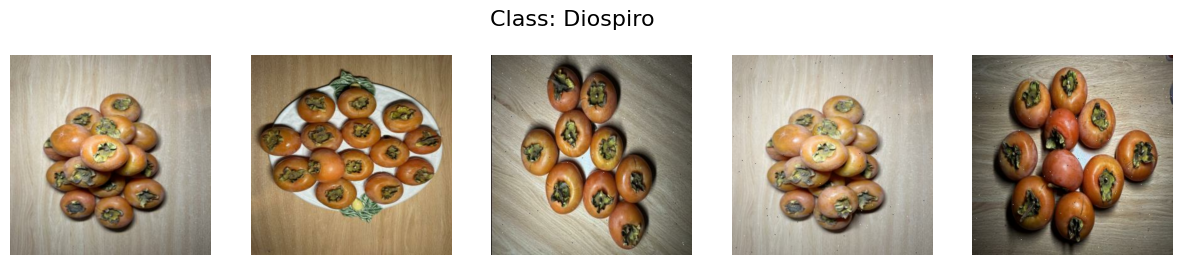

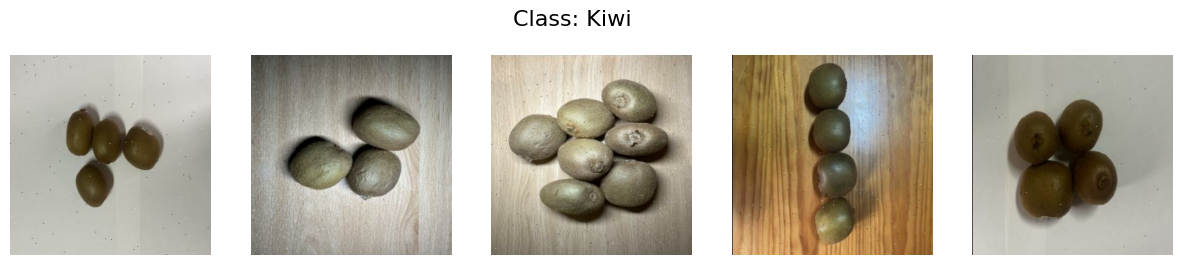

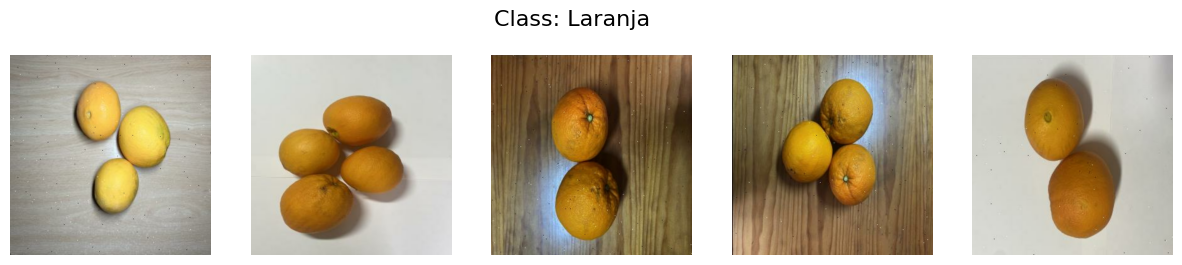

In [ ]:
images_by_class = {class_name: [] for class_name in class_names}

for images, labels in train_set.take(-1):
    images_np = images.numpy().astype("uint8")
    labels_np = labels.numpy()

    for img, label in zip(images_np, labels_np):
        class_idx = tf.argmax(label).numpy()
        class_name = class_names[class_idx]

        if len(images_by_class[class_name]) < 5:
            images_by_class[class_name].append(img)

    if all(len(img_list) == 5 for img_list in images_by_class.values()):
        break

for class_name, images in images_by_class.items():
    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Class: {class_name}", fontsize=16)
    for i, img in enumerate(images):
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

In [ ]:
# normalização das imagens
train_set = train_set.map(lambda x, y: (x / 255.0, y))
val_set = val_set.map(lambda x, y: (x / 255.0, y))
test_set = test_set.map(lambda x, y: (x / 255.0, y))

# Construaço do modelo

In [ ]:
import tensorflow.keras as keras
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

# inicializar modelo
#base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
import tensorflow.keras as keras
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models

base_model = keras.applications.ResNet50V2(
    include_top=False,
    weights="imagenet",
    #input_tensor=None,
    input_shape=(520, 520, 3),
    pooling="avg",
    #classes=1000,
    #classifier_activation="softmax",
)

# congelar todas as layers
for layer in base_model.layers:
    layer.trainable = False

# descongelar as últimas 50 layers
for layer in base_model.layers[-100:]:
    layer.trainable = True

# adicionar uma nova layer de saída ao modelo, para classificar as classes corretas
model = models.Sequential([
    base_model,
    #layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='softmax')  # 5 classes
])

# compilar modelo
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Early stopping callback para parar o treino quando não existe melhoria da validation loss
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,               # pára o treino após 5 épocas
    restore_best_weights=True # reverter os pesos do treino para os melhores obtidos
)

# Reduce learning rate callback para atualizar o learning rate quando não existe melhoria da validation loss
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,               # reduzir learning rate por um fator de 0.1
    patience=3,               # atualiza após 3 épocas
    min_lr=1e-10              # learning rate mínimo
)

model_checkpoint = ModelCheckpoint('/content/model_checkpoint.keras', save_best_only=True, monitor='val_loss', mode='min'),

In [ ]:
# treinar o modelo
history = model.fit(train_set,
                    batch_size = 32,
                    epochs=100,
                    validation_data=val_set,
                    callbacks=[early_stopping, reduce_lr, model_checkpoint])

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.2441 - loss: 1.5575 - val_accuracy: 0.4224 - val_loss: 1.1340 - learning_rate: 1.0000e-04
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 788ms/step - accuracy: 0.4449 - loss: 1.1276 - val_accuracy: 0.6921 - val_loss: 0.9710 - learning_rate: 1.0000e-04
Epoch 3/100
 5/44 ━━━━━━━━━━━━━━━━━━━━ 24s 634ms/step - accuracy: 0.6054 - loss: 0.8506

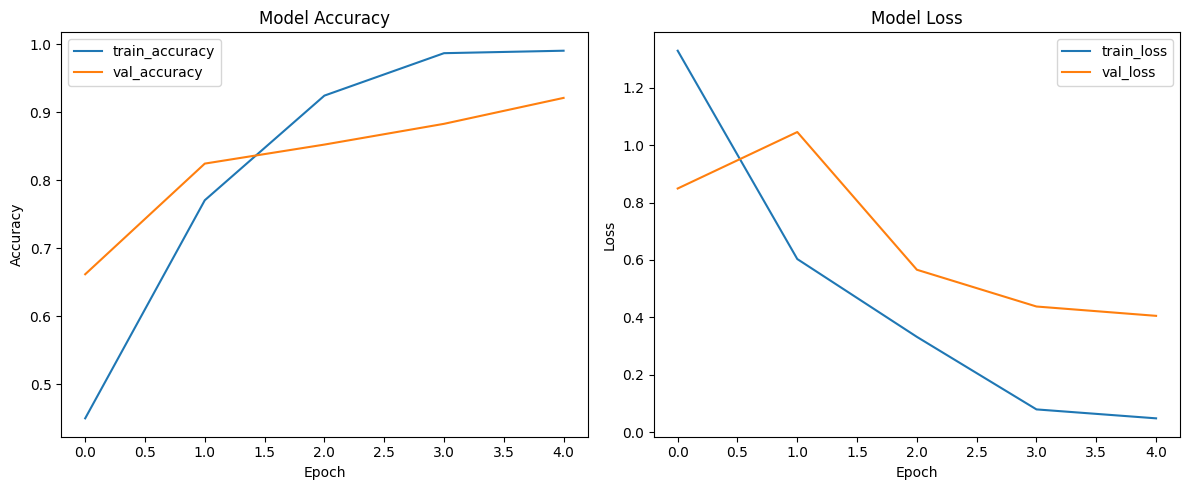

In [ ]:
# criar figura
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='train_accuracy')
axes[0].plot(history.history['val_accuracy'], label='val_accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_title('Model Accuracy')

# Loss plot
axes[1].plot(history.history['loss'], label='train_loss')
axes[1].plot(history.history['val_loss'], label='val_loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].set_title('Model Loss')

plt.tight_layout()
plt.show()

In [ ]:
# avaliar treino com base nos dados de teste
test_loss, test_accuracy = model.evaluate(test_set)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 473ms/step - accuracy: 0.7546 - loss: 0.6430
Test accuracy: 74.49%


In [ ]:
def test_confusion_matrix(model, test_set, class_names):

    # labels e previsões
    y_true = []
    y_pred = []

    for images, labels in test_set:
        predictions = model.predict(images)
        y_pred.extend(np.argmax(predictions, axis=1))  # Previsão da classe


        if labels.shape[-1] > 1:
            y_true.extend(np.argmax(labels, axis=1))
        else:
            y_true.extend(labels.numpy())

    # lista para array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Generate classification report
    print("\n Relatório de Classificação:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    # matrix de confusão
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Matriz de Confusão")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

 Relatório de Classificação:
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00        39
      Batata       1.00      0.70      0.83        44
    Diospiro       1.00      1.00      1.00        32
        Kiwi       0.57      0.94      0.71        18
     Laranja       0.98      1.00      0.99        63

    accuracy                           0.93       196
   macro avg       0.91      0.93      0.91       196
weighted avg       0.96      0.93      0.93       196



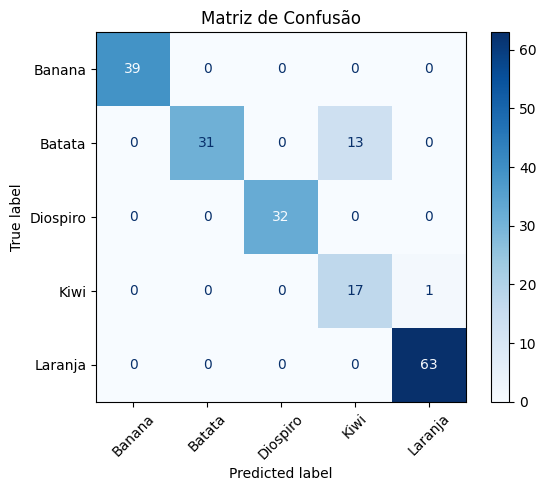

In [ ]:
test_confusion_matrix(model, test_set, class_names)

In [ ]:
# Define the path and input size
image_path = "/content/Kiwi_(Actinidia_chinensis)_1_Luc_Viatour.jpg"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Kiwi_(Actinidia_chinensis)_1_Luc_Viatour.jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted class: Banana with confidence: 55.98%


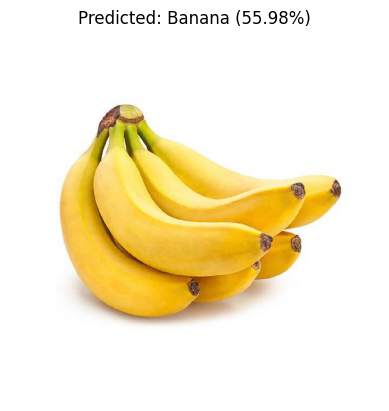

In [ ]:
# Define the path and input size
image_path = "/content/WhatsApp Image 2024-12-06 at 17.38.52.jpeg"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted class: Batata with confidence: 53.93%


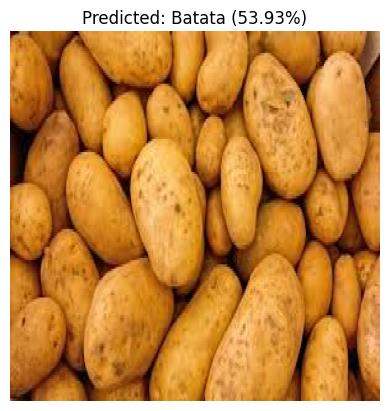

In [ ]:
# Define the path and input size
image_path = "/content/WhatsApp Image 2024-12-06 at 17.39.51.jpeg"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted class: Diospiro with confidence: 100.00%


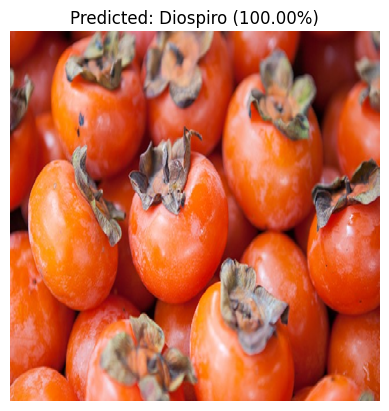

In [ ]:
# Define the path and input size
image_path = "/content/WhatsApp Image 2024-12-06 at 17.40.52.jpeg"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted class: Laranja with confidence: 100.00%


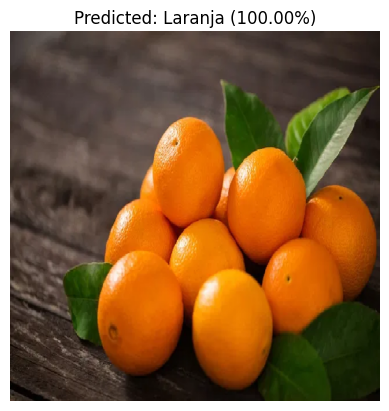

In [ ]:
# Define the path and input size
image_path = "/content/beneficios-da-laranja_53623_l.jpg-2.webp"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted class: Kiwi with confidence: 100.00%


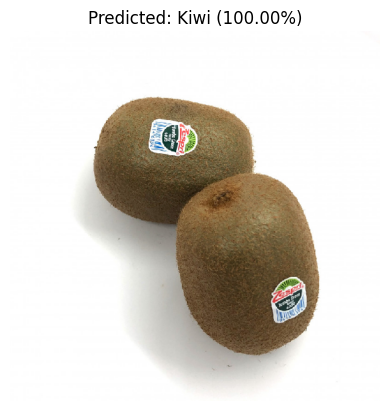

In [ ]:
# Define the path and input size
image_path = "/content/kiwis-green.jpg"
input_size = (590, 590)  # Define the input size used during training

# Load the image and resize to the model's expected input size
img = load_img(image_path, target_size=input_size)

# Convert the image to an array and normalize (to range [0, 1] if needed)
img_array = img_to_array(img) / 255.0  # Normalize as done in training

# Add an extra batch dimension since the model expects a batch of images
img_array = np.expand_dims(img_array, axis=0)

# Predict using the model
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# Print results
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

# Display the image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")  # Hide axes for a cleaner look
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Função para plotar as curvas ROC para todas as classes
def plot_roc_all_classes(model, test_set, class_names):
    y_true = []
    y_scores = []

    for images, labels in test_set:
        predictions = model.predict(images)
        y_scores.extend(predictions)

        if labels.shape[-1] > 1:
            y_true.extend(labels.numpy())
        else:
            y_true.extend(keras.utils.to_categorical(labels.numpy(), num_classes=len(class_names)))

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    plt.figure(figsize=(10, 8))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.5f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title("Curvas ROC para Todas as Classes")
    plt.xlabel("Taxa de Falsos Positivos (FPR)")
    plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


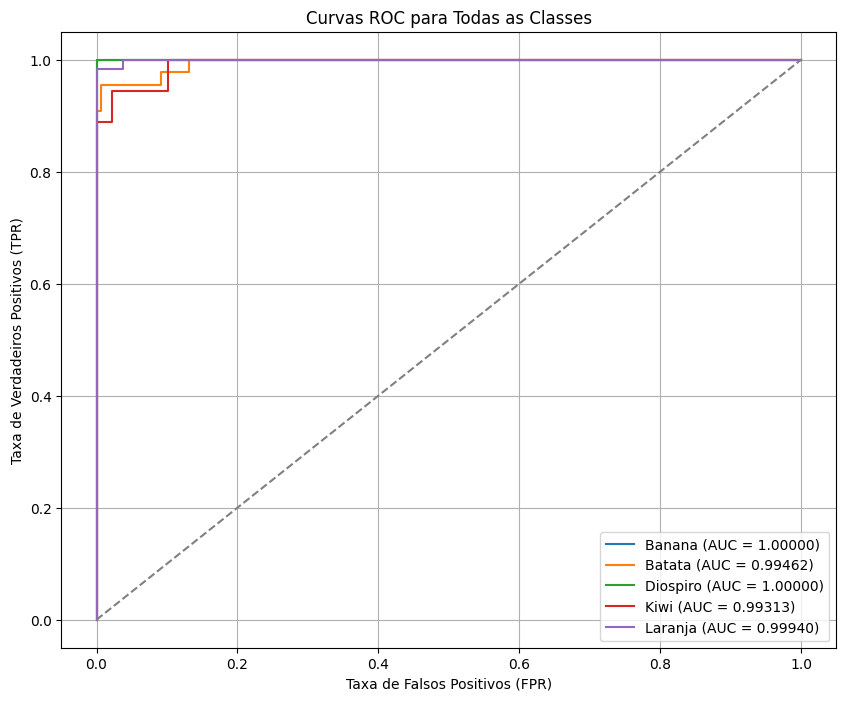

In [ ]:
# Gerar curvas ROC para todas as classes
plot_roc_all_classes(model, test_set, class_names)
